# Prédictions U-Net sur l’échantillon de test

In [1]:
import os
import sys
import random
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from PIL import Image
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from IPython.display import display

# Exécution depuis Debut/UNet, Debut ou la racine du dépôt.
cwd = Path.cwd().resolve()
unet_candidates = (cwd, cwd / "UNet", cwd / "Debut/UNet")
UNET_DIR = next((path for path in unet_candidates
                  if (path / "models/CSANet.py").is_file()), None)
if UNET_DIR is None:
    attempted = "\n".join(f"- {path}" for path in unet_candidates)
    raise FileNotFoundError("Dossier UNet introuvable. Emplacements testés :\n" + attempted)
PROJECT_DIR = UNET_DIR.parent
sys.path.insert(0, str(UNET_DIR.parent))
sys.path.insert(0, str(UNET_DIR))
from utils.dataset_unet import RoboflowUNetDataset, EggHVDataset
from utils.dataset_2_5D import SliceSequenceUNetDataset
from utils.models_config import (collate_fn, collate_fn_egg_hv, collate_fn_sequence,
                                split_dataset, dataset_to_dict)
from utils.unet_spatial import unpad_array
from utils.segmentation_metrics import metrics_by_class
from utils.segmentation_visualization import overlay_colored_mask, plot_segmentation_comparison
from utils.yolo_metrics import mask_to_yolo_polygons
from utils.post_traitement import keep_largest_components, fill_holes, split_eggs
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.CSANet import CSANet
from models.EggSegmentationHVUNet import EggSegmentationHVUNet, postprocess_egg_instances

/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration et reproductibilité

In [2]:
MODEL_NAME = "UNet"  # UNet, AttentionUNet++, EggSegmentationHVUNet, CSANet
DATASET_NAME = "2classes"  # 2classes, 3classes, oeufs ; CSA-Net : 3classes uniquement
IGNORE = False  # Même convention que les notebooks d’évaluation
IMAGE_SIZE = (512, 512)
THRESHOLD = 0.5
K_FOLDS = 5

In [11]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

SUPPORTED_DATASETS = {
    "UNet": {"2classes", "3classes", "oeufs"},
    "AttentionUNet++": {"2classes", "3classes", "oeufs"},
    "EggSegmentationHVUNet": {"oeufs"},
    "CSANet": {"3classes"},
}
if MODEL_NAME not in SUPPORTED_DATASETS or DATASET_NAME not in SUPPORTED_DATASETS[MODEL_NAME]:
    raise ValueError(f"Configuration non prise en charge : {MODEL_NAME} / {DATASET_NAME}. "
                     f"Configurations : {SUPPORTED_DATASETS}")
IS_SEQUENCE = MODEL_NAME == "CSANet"
IS_HV = MODEL_NAME == "EggSegmentationHVUNet"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil : {device}, IGNORE={IGNORE}")

Appareil : cuda, IGNORE=False


### Données et découpage commun par poisson

In [12]:
DATASET_CONFIG = {
    "2classes": {"images": "cavite", "annotations": "cavite/annotations_2_classes.json"},
    "3classes": {"images": "cavite", "annotations": "cavite/annotations.json"},
    "oeufs": {"images": "oeufs", "annotations": "oeufs/annotations.oeufs.json"},
}
config = DATASET_CONFIG[DATASET_NAME]
images_path = PROJECT_DIR / "data/COCO/images" / config["images"]
annotations_path = PROJECT_DIR / "data/COCO/labels" / config["annotations"]
metadata_path = PROJECT_DIR / "utils/correspondance_echo_final.xlsx"
required_paths = {"images": images_path, "annotations": annotations_path,
                  "métadonnées": metadata_path}
missing = [f"{label}: {path}" for label, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Données requises introuvables :\n" + "\n".join(missing))
images_dir = str(images_path)
annotations_json = str(annotations_path)
df = pd.read_excel(metadata_path,
                   dtype={"annee": str, "image_id": str, "new_name_file": str})
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(
    df, annotations_json, images_dir)
gonade_id = class_ids.index(next((cid for cid, name in categories.items() if name == "Gonade"),
                                class_ids[0])) if ignore_category_id is not None else None
class_names = [categories[cid] for cid in class_ids]
cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test = split_dataset(all_samples)
assert set(groups_train).isdisjoint(set(groups_test))
print(f"Modèle : {MODEL_NAME}, données : {DATASET_NAME}, classes : {class_names}")

Classes détectées (2) : {1: 'Cavite', 2: 'Gonade'}
Catégorie ignore détectée : 'ignore' (id=4)
Nombre total d'images valides : 169
Échantillons train/val        : 145
Échantillons de test          : 24
Modèle : UNet, données : 2classes, classes : ['Cavite', 'Gonade']


In [13]:
def build_dataset(samples):
    if IS_HV:
        if not class_ids:
            raise ValueError("Aucune catégorie COCO disponible pour le modèle HV.")
        return EggHVDataset(samples=samples, image_size=IMAGE_SIZE, is_train=False,
                            egg_category_id=class_ids[0]), collate_fn_egg_hv
    dataset_class = SliceSequenceUNetDataset if IS_SEQUENCE else RoboflowUNetDataset
    dataset = dataset_class(samples=samples, image_dir=images_dir, df=df, image_size=IMAGE_SIZE,
                            num_classes=num_classes, class_ids=class_ids, is_train=False,
                            ignore_category_id=ignore_category_id,
                            ignore_target_class_idx=gonade_id if IGNORE else None)
    return dataset, collate_fn_sequence if IS_SEQUENCE else collate_fn

test_dataset, test_collate = build_dataset(test_samples)
if not len(test_dataset):
    raise ValueError("Le dataset de test ne contient aucune image ou séquence exploitable.")
test_loader = DataLoader(test_dataset, batch_size=1 if IS_SEQUENCE else 4,
                         shuffle=False, collate_fn=test_collate)
nb_channels = test_dataset[0]["image"].shape[-3]
meta_by_name = {Path(s["image_info"]["file_name"]).name: s for s in test_samples}
echelle_cm_by_name = {}
for name in meta_by_name:
    rows = df.loc[df["image_id"] == name.split("_")[0], "echelle"]
    if rows.empty or not np.isfinite(float(rows.iloc[0])) or float(rows.iloc[0]) <= 0:
        raise ValueError(f"Échelle absente ou invalide : {name}")
    echelle_cm_by_name[name] = float(rows.iloc[0])
print(f"Forme du premier élément : {test_dataset[0]['image'].shape}")

Forme du premier élément : torch.Size([3, 512, 512])


### Chargement des cinq folds

In [14]:
def build_model():
    # Les checkpoints contiennent tous les poids : aucun téléchargement ImageNet.
    if MODEL_NAME == "UNet":
        return smp.Unet(encoder_name="resnet34", encoder_weights=None,
                        in_channels=nb_channels, classes=num_classes, activation=None)
    if MODEL_NAME == "AttentionUNet++":
        return ResAttentionUNetPlusPlus(num_classes=num_classes, in_channels=nb_channels,
                                        encoder_weights=None)
    if IS_HV:
        return EggSegmentationHVUNet(in_channels=nb_channels, encoder_weights=None)
    return CSANet(num_classes=num_classes, in_channels=nb_channels, encoder_weights=None)

checkpoint_paths = [UNET_DIR / "saves" / f"unet_finetuned_fold_{fold}_{MODEL_NAME}_{DATASET_NAME}.pth"
                    for fold in range(1, K_FOLDS + 1)]
missing = [str(path) for path in checkpoint_paths if not path.is_file()]
if missing:
    raise FileNotFoundError("Checkpoints introuvables :\n" + "\n".join(missing))
models_ensemble = []
for path in checkpoint_paths:
    model = build_model()
    model.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    models_ensemble.append(model.to(device).eval())
print(f"{len(models_ensemble)} folds chargés.")

5 folds chargés.


### Inférence et post-traitement communs à toutes les visualisations

In [15]:
def unpack_batch(batch):
    images = batch["image"].to(device)
    if IS_SEQUENCE:
        display_images = images.squeeze(0)
        targets = batch["mask"].to(device).squeeze(0)
        names = [Path(path).name for path in batch["image_path"][0]]
        sizes = batch["original_size"][0]
    else:
        display_images = images
        targets = batch["mask"].to(device)
        names = ([Path(path).name for path in batch["image_path"]]
                 if IS_HV else batch["file_names"])
        sizes = batch["original_size"]
    if IS_HV:
        targets = targets[:, :1]  # Les deux autres canaux sont les cibles horizontal/vertical.
    return images, display_images, targets, names, sizes

@torch.inference_mode()
def predict_batch(batch):
    images, display_images, targets, names, sizes = unpack_batch(batch)
    probs = torch.zeros_like(targets)
    hv_sum = None
    for model in models_ensemble:
        outputs = model(images)
        if IS_SEQUENCE:
            outputs = outputs.squeeze(0)
        if IS_HV:
            hv_sum = outputs.clone() if hv_sum is None else hv_sum + outputs
            outputs = outputs[:, :1]
        probs += torch.sigmoid(outputs)
    probs /= len(models_ensemble)
    valid = targets != -100
    true = (targets > THRESHOLD) & valid
    pred = (probs > THRESHOLD) & valid
    instances = None
    if DATASET_NAME == "oeufs":
        if IS_HV:
            instances = torch.stack([torch.from_numpy(postprocess_egg_instances(
                output, mask_threshold=THRESHOLD)[1]) for output in hv_sum / len(models_ensemble)]).to(device)
        else:
            instances = split_eggs(pred, min_distance=4, min_area=100,
                                   ouverture_size=3, ouverture_iterations=1)
        pred = (instances > 0).unsqueeze(1) & valid
    else:
        pred = fill_holes(keep_largest_components(pred)) & valid
    return display_images, true, pred, probs, instances, names, sizes

def batch_metrics(batch, true, pred, instances, names, sizes):
    scales = torch.tensor([echelle_cm_by_name[name] for name in names],
                          device=device, dtype=torch.float32).view(-1, 1)
    return metrics_by_class(
        true, pred, scales, DATASET_NAME,
        egg_instance_labels=instances if DATASET_NAME == "oeufs" else None,
        egg_annotation_areas_px=batch["egg_annotation_areas_px"] if DATASET_NAME == "oeufs" else None,
        # L'échelle couvre la hauteur du crop original, avant padding U-Net.
        image_height_px=[size[1] for size in sizes],
    )

### Prédictions complètes, métriques et exports
Chaque ligne de résultats correspond à une image et une classe. Les noms et catégories suivent l’ordre réel des coupes prédites.

In [19]:
results_dir = UNET_DIR / "results/test" / MODEL_NAME / DATASET_NAME
masks_dir = UNET_DIR / "masks/test" / MODEL_NAME / DATASET_NAME
results_dir.mkdir(parents=True, exist_ok=True)
masks_dir.mkdir(parents=True, exist_ok=True)
rows = []
seen_names = []
for batch in test_loader:
    images, true, pred, probs, instances, names, sizes = predict_batch(batch)
    intersection, union, iou, dice, precision, recall, diff_surface = batch_metrics(
        batch, true, pred, instances, names, sizes)
    true_surface = true.float().sum((2, 3))
    pred_surface = pred.float().sum((2, 3))
    ratio_surface = (true_surface - pred_surface).abs() / (true_surface + 1e-6)
    for i, name in enumerate(names):
        seen_names.append(name)
        sample = meta_by_name[name]
        for c, label in enumerate(class_names):
            rows.append({"name": name, "category": sample["category"],
                         "iou": iou[i, c].item(), "dice": dice[i, c].item(),
                         "precision": precision[i, c].item(), "recall": recall[i, c].item(),
                         "diff_surface": diff_surface[i, c].item(),
                         "ratio_surface": ratio_surface[i, c].item(),
                         "intersection": intersection[i, c].item(), "union": union[i, c].item(),
                         "true_surface_px": true_surface[i, c].item(),
                         "pred_surface_px": pred_surface[i, c].item()})
        stem = Path(name).stem
        # Dépadding avant affichage et export dans le référentiel cropé (510 × 380).
        image_crop = unpad_array(images[i]).cpu()
        if DATASET_NAME == "oeufs":
            # Conserver les identifiants du split / post-traitement HV pour les couleurs.
            true_instances = split_eggs(true[i:i + 1], min_distance=8, min_area=100,
                                       ouverture_size=3, ouverture_iterations=1)[0]
            true_crop = unpad_array(true_instances).cpu()
            pred_crop = unpad_array(instances[i]).cpu()
        else:
            true_crop = unpad_array(true[i]).cpu()
            pred_crop = unpad_array(pred[i]).cpu()
        combined = np.hstack((
            overlay_colored_mask(image_crop, true_crop, alpha=0.4,
                                 dataset_name=DATASET_NAME, class_names=class_names),
            overlay_colored_mask(image_crop, pred_crop, alpha=0.4,
                                 dataset_name=DATASET_NAME, class_names=class_names),
        ))
        Image.fromarray(combined).save(results_dir / f"{stem}.png")
        polygons = []
        for c in range(num_classes):
            polygons.extend(mask_to_yolo_polygons(unpad_array(pred[i, c]), c, target_size=(510, 380)))
        (masks_dir / f"pred_{stem}.txt").write_text("\n".join(polygons) + ("\n" if polygons else ""))

results_by_image = pd.DataFrame(rows)
if results_by_image.empty:
    raise ValueError("Aucune image testée.")
assert len(seen_names) == len(set(seen_names)), "Une image a été prédite plusieurs fois."
excluded_names = sorted(set(meta_by_name) - set(seen_names))
print(f"{len(seen_names)} images prédites ; {len(excluded_names)} images exclues par le dataset.")
if excluded_names:
    print("Images exclues (positions manquantes pour les séquences) :", excluded_names)
display(results_by_image)

24 images prédites ; 0 images exclues par le dataset.


,name,category,iou,dice,precision,recall,diff_surface,ratio_surface,intersection,union,true_surface_px,pred_surface_px
0,0004597_12.17.08_356434_2019.jpg,debut,0.938794,0.968431,0.978620,0.958452,0.0748,0.020609,34787.0,37055.0,36295.0,35547.0
1,0004597_12.17.08_356434_2019.jpg,debut,0.713002,0.832459,0.945535,0.743540,0.4150,0.213631,14444.0,20258.0,19426.0,15276.0
2,0004598_12.17.20_356434_2019.jpg,milieu,0.929396,0.963406,0.987519,0.940442,0.1845,0.047672,36397.0,39162.0,38702.0,36857.0
3,0004598_12.17.20_356434_2019.jpg,milieu,0.687756,0.814995,0.881622,0.757730,0.2645,0.140527,14262.0,20737.0,18822.0,16177.0
4,0004599_12.17.26_356434_2019.jpg,milieu,0.943741,0.971056,0.980198,0.962084,0.0464,0.018480,24156.0,25596.0,25108.0,24644.0
5,0004599_12.17.26_356434_2019.jpg,milieu,0.842687,0.914629,0.984950,0.853679,0.2963,0.133276,18979.0,22522.0,22232.0,19269.0
6,0004600_12.17.38_356434_2019.jpg,fin,0.930731,0.964123,0.952342,0.976199,0.0361,0.025050,14068.0,15115.0,14411.0,14772.0
7,0004600_12.17.38_356434_2019.jpg,fin,0.796905,0.886975,0.940449,0.839255,0.1063,0.107602,8291.0,10404.0,9879.0,8816.0
8,0004647_11.15.45_356859_2019.jpg,debut,0.917949,0.957220,0.924250,0.992628,0.1987,0.073982,26660.0,29043.0,26858.0,28845.0
9,0004647_11.15.45_356859_2019.jpg,debut,0.751464,0.858098,0.913015,0.809413,0.1367,0.113472,9751.0,12976.0,12047.0,10680.0


### Résultats globaux et sauvegarde
Les différences de surface restent indéfinies (`NaN`) lorsqu’une surface réelle ou prédite est absente, comme dans les notebooks d’évaluation. Les moyennes ignorent ces valeurs.


In [17]:
summary_rows = []
for label, frame in results_by_image.groupby("classe", sort=False):
    tp = frame["intersection"].sum()
    union = frame["union"].sum()
    predicted = frame["pred_surface_px"].sum()
    target = frame["true_surface_px"].sum()
    summary_rows.append({"classe": label, "mean_iou": frame["iou"].mean(),
                         "dataset_iou": tp / (union + 1e-6),
                         "dice": 2 * tp / (predicted + target + 1e-6),
                         "precision": tp / (predicted + 1e-6), "recall": tp / (target + 1e-6),
                         "mean_diff_surface": frame["diff_surface"].mean(),
                         "mean_ratio_surface": frame["ratio_surface"].mean()})
summary = pd.DataFrame(summary_rows).set_index("classe")
surface_unit = "mm²" if DATASET_NAME == "oeufs" else "cm²"
print(f"Différences de surface en {surface_unit}")
display(summary)
results_path = results_dir / f"results_test_{MODEL_NAME}_{DATASET_NAME}.pkl"
with results_path.open("wb") as f:
    pickle.dump({"model": MODEL_NAME, "dataset": DATASET_NAME, "ignore": IGNORE,
                 "threshold": THRESHOLD, "folds": K_FOLDS, "surface_unit": surface_unit,
                 "class_names": class_names, "results_by_image": results_by_image,
                 "summary": summary, "excluded_names": excluded_names}, f)
print(f"Résultats sauvegardés : {results_path}")

Différences de surface en cm²


,mean_iou,dataset_iou,dice,precision,recall,mean_diff_surface,mean_ratio_surface
classe,,,,,,,
Cavite,0.92531,0.926813,0.962017,0.966092,0.957975,0.086362,0.038248
Gonade,0.74641,0.738184,0.849374,0.873267,0.826753,0.187071,0.170581


Résultats sauvegardés : /home/ldepiero/Stage-GonAIde-2026/Debut/UNet/results/test/UNet/2classes/results_test_UNet_2classes.pkl


In [22]:
def plot_boxplot(datasets, labels, colors, size=(6, 4), limite_echelle=np.arange(0, 1.01, 0.05)):
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=size)

    # Si un seul graphique, axes n'est pas une liste
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):

        # Création du boxplot
        boxplot = ax.boxplot(datasets[i], patch_artist=True)

        # Labels
        ax.set_xticks(range(1, len(labels[i]) + 1))
        ax.set_xticklabels(labels[i])

        # Couleurs
        for patch, color in zip(boxplot["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.4)
            patch.set_edgecolor(color)

        # Médianes
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

        # Grille
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")

        # Échelle
        ax.set_yticks(limite_echelle)
        ax.set_ylim(limite_echelle[0], limite_echelle[-1])

    plt.tight_layout()
    plt.show()


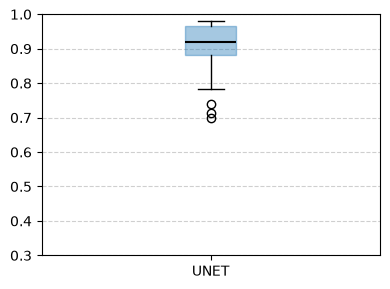

In [32]:
data = [results_by_image.dice]
labels = ["UNET"]
colors = ["#1f77b4"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.3, 1.01, 0.1)
plot_boxplot([data], [labels], colors, size=(4, 3), limite_echelle=limite)

### Visualisation d’une image du test
Pour CSA-Net, la séquence complète du poisson est prédite avant de sélectionner la coupe.

,iou,dice,precision,recall,diff_surface
classe,,,,,
Cavite,0.938794,0.968431,0.97862,0.958452,0.0748
Gonade,0.713348,0.832695,0.94556,0.743900,0.4143


0004597_12.17.08_356434_2019.jpg


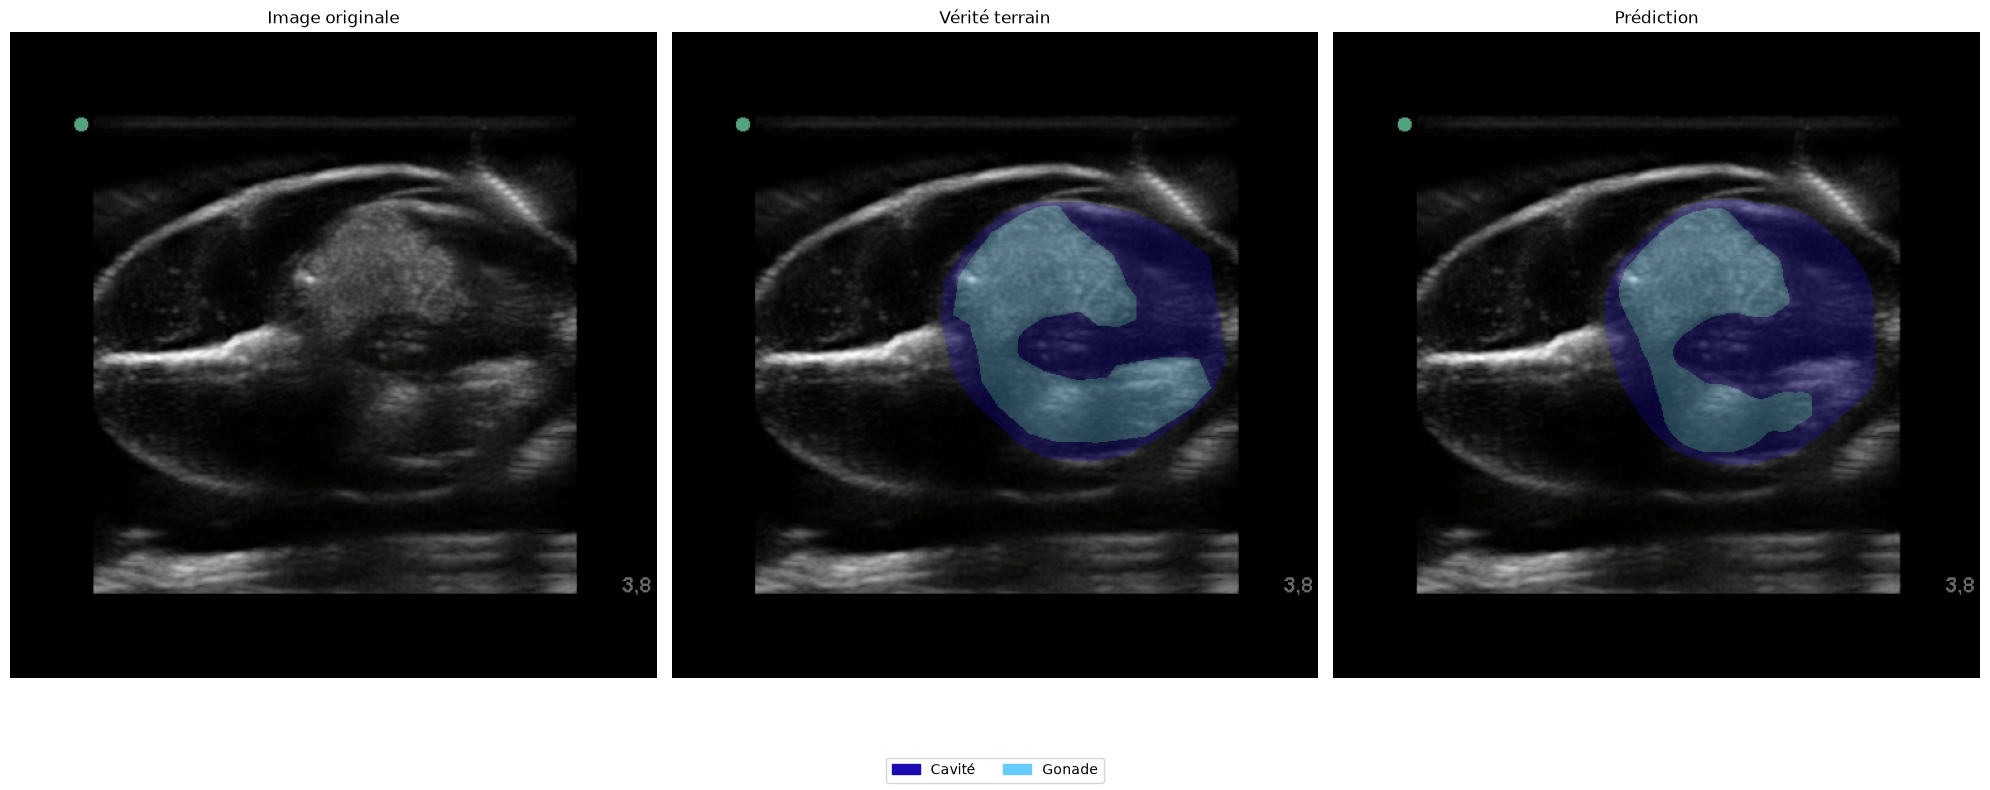

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>,
        <Axes: title={'center': 'Vérité terrain'}>,
        <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [10]:
VIS_FILENAME = None  # Nom exact d’une image du test ; prioritaire sur VIS_INDEX
VIS_INDEX = 0  # Index dans l’ordre réel des images du dataset de test
VIS_CLASS = 0  # Index de classe pour la carte de probabilités
PROB_THRESHOLD = 0.3

ordered_names = []
locations = {}
for dataset_index in range(len(test_dataset)):
    item = test_dataset[dataset_index]
    paths = item["image_path"] if IS_SEQUENCE else [item["image_path"]]
    for slice_index, path in enumerate(paths):
        name = Path(path).name
        ordered_names.append(name)
        locations[name] = (dataset_index, slice_index)
if VIS_FILENAME is not None and str(VIS_FILENAME).strip():
    selected_name = Path(str(VIS_FILENAME).strip()).name
    if selected_name not in locations:
        raise ValueError(f"Image absente du test exploitable : {selected_name}")
else:
    if not 0 <= VIS_INDEX < len(ordered_names):
        raise IndexError(f"VIS_INDEX doit être compris entre 0 et {len(ordered_names) - 1}.")
    selected_name = ordered_names[VIS_INDEX]
if not 0 <= VIS_CLASS < num_classes:
    raise IndexError(f"VIS_CLASS doit être compris entre 0 et {num_classes - 1}.")
dataset_index, slice_index = locations[selected_name]
vis_batch = test_collate([test_dataset[dataset_index]])
vis_images, vis_true, vis_pred, vis_probs, vis_instances, vis_names, vis_sizes = predict_batch(vis_batch)
vis_metrics = batch_metrics(vis_batch, vis_true, vis_pred, vis_instances, vis_names, vis_sizes)
_, _, iou, dice, precision, recall, diff_surface = vis_metrics
display(pd.DataFrame([{"classe": label, "iou": iou[slice_index, c].item(),
                       "dice": dice[slice_index, c].item(), "precision": precision[slice_index, c].item(),
                       "recall": recall[slice_index, c].item(), "diff_surface": diff_surface[slice_index, c].item()}
                      for c, label in enumerate(class_names)]).set_index("classe"))
print(selected_name)
if DATASET_NAME == "oeufs":
    vis_true_display = split_eggs(vis_true[slice_index:slice_index + 1], min_distance=8,
                                  min_area=100, ouverture_size=3, ouverture_iterations=1)[0]
    vis_pred_display = vis_instances[slice_index]
else:
    vis_true_display = vis_true[slice_index]
    vis_pred_display = vis_pred[slice_index]
plot_segmentation_comparison(vis_images[slice_index].cpu(), vis_true_display.cpu(),
                             vis_pred_display.cpu(), is_eggs=DATASET_NAME == "oeufs", alpha=0.3)